In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
from category_encoders import TargetEncoder


1. penalty: Literal['l1', 'l2', 'elasticnet'] | None = "l2"
   model=LinearRegression(penalty='l1')
   model=LinearRegression(penalty='l2')
   model=LinearRegression(penalty='elasticney')

2. solver is an optimization engine which helps gradient descent to optimize the weights.

* l1_ratio=0 means only l2
* l1_ratio=1 means only l1

solver: Literal['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'] = "lbfgs"


solver	              l1_ratio	             multinomial multiclass
'lbfgs'	             l1_ratio=0	                      yes
'liblinear'	     l1_ratio=1 or l1_ratio=0	          no
'newton-cg'	         l1_ratio=0	                      yes
'newton-cholesky'	 l1_ratio=0	                      yes
'sag'	             l1_ratio=0	                      yes
'saga'	           0<=l1_ratio<=1	                  yes

3. max_iter: Int = 100,

* if we have more number of data we can increase the iteraions, 
* uses tolerance to stop the iteration once the best weights are reached,
* tol: Float = 0.0001 # dont change the tol keep it default

4. class_weight: Mapping | str | None = None

* class_weight= None | 'balanced'
* we use it when we have imbalanced data 
* we can use valuecount() method to find count of unique values in target column, if the count difference btw two labels is high then we apply balance

5. C: Float = 1

* Tells the regularization strength
* this parameter decides whether the model is going to be underfit,goodfit or overfit


In [2]:
df=pd.read_csv('loan_approval_dataset.csv')

In [3]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Salary             1000 non-null   int64 
 2   Credit_Score       1000 non-null   int64 
 3   Loan_Amount        1000 non-null   int64 
 4   Loan_Term          1000 non-null   object
 5   Employment_Status  1000 non-null   object
 6   Residence_Type     1000 non-null   object
 7   Previous_Default   1000 non-null   object
 8   Loan_Approved      1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [5]:
x=df.drop(columns='Loan_Approved')
y=df['Loan_Approved']

In [6]:
obj_cols=x.select_dtypes(include='object').columns
num_cols=x.select_dtypes(include='number').columns

In [7]:
x.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: >

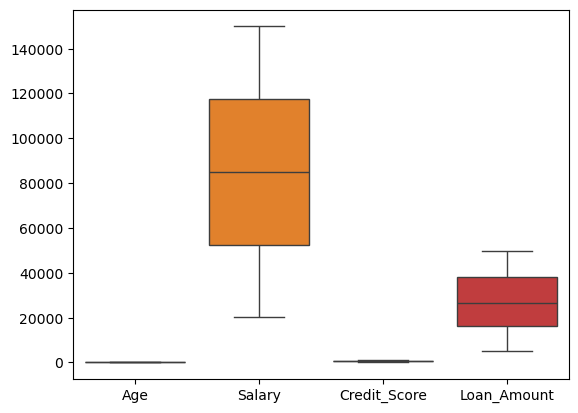

In [9]:
sns.boxplot(x[num_cols])

* Since there are no outliers we use MinMaxScaler for scaling of numerical columns

In [10]:
x[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

* Since we have less unique values we can use OneHotEncoder

# Preprocessing Technique

* Scaling
* Encoding

Why scaling ?

* Numerical columns are in different ranges so we can use scaling to give equal importance for all the feature columns

Why Encoding ?

Which Scaling and Encoding techniques we can use for this ?

Scaling :
    1.MinMaxScaler - has there are no outliers
    2.StandardScaler - We use StandardScaler when the data has different ranges and may contain outliers

Encoding :
    1.OneHotEncoder

In [17]:
scaler=MinMaxScaler()

encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)

model=LogisticRegression()

In [13]:
# model.fit(xtrain,ytrain) ValueError: could not convert string to float: '24 months'
# We cant directly train the model without encoding and scaling

# Scaling

In [14]:
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
x_test[num_cols]=scaler.transform(x_test[num_cols])

In [15]:
x_train

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default
29,0.565217,0.503206,0.377737,0.267437,24 months,Self-Employed,Rented,No
535,0.434783,0.517503,0.344891,0.125955,36 months,Employed,Mortgage,No
695,0.586957,0.227507,0.843066,0.766342,36 months,Employed,Mortgage,No
557,0.630435,0.425421,0.928832,0.792145,12 months,Employed,Mortgage,Yes
836,0.608696,0.623919,0.372263,0.599124,36 months,Unemployed,Mortgage,No
...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,36 months,Employed,Rented,No
270,0.173913,0.889773,0.160584,0.388186,48 months,Self-Employed,Mortgage,Yes
860,1.000000,0.884776,0.698905,0.078281,36 months,Unemployed,Rented,No
435,0.173913,0.213857,0.987226,0.906103,36 months,Unemployed,Mortgage,No


In [16]:
x_test

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default
521,0.152174,0.220886,0.521898,0.540280,36 months,Self-Employed,Mortgage,No
737,0.434783,0.687894,0.020073,0.453711,12 months,Unemployed,Mortgage,No
740,0.347826,0.836468,0.760949,0.652294,24 months,Self-Employed,Rented,Yes
660,0.434783,0.315031,0.950730,0.116550,24 months,Employed,Rented,No
411,0.934783,0.605720,0.693431,0.587172,12 months,Unemployed,Rented,No
...,...,...,...,...,...,...,...,...
408,0.782609,0.894307,0.270073,0.867633,36 months,Unemployed,Mortgage,No
332,0.347826,0.976689,0.764599,0.938296,12 months,Employed,Mortgage,Yes
208,0.478261,0.012071,0.034672,0.038805,36 months,Unemployed,Rented,Yes
613,0.086957,0.540937,0.791971,0.830012,36 months,Unemployed,Mortgage,Yes


# Encoding

In [20]:
values=encoder.fit_transform(x_train[obj_cols])
cols=encoder.get_feature_names_out()
cols

array(['Loan_Term_12 months', 'Loan_Term_24 months',
       'Loan_Term_36 months', 'Loan_Term_48 months',
       'Employment_Status_Employed', 'Employment_Status_Self-Employed',
       'Employment_Status_Unemployed', 'Residence_Type_Mortgage',
       'Residence_Type_Owned', 'Residence_Type_Rented',
       'Previous_Default_No', 'Previous_Default_Yes'], dtype=object)

In [21]:
x_train[cols]=values
x_train

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,24 months,Self-Employed,Rented,No,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,36 months,Employed,Mortgage,No,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,36 months,Employed,Mortgage,No,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,12 months,Employed,Mortgage,Yes,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,36 months,Unemployed,Mortgage,No,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,36 months,Employed,Rented,No,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,48 months,Self-Employed,Mortgage,Yes,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,36 months,Unemployed,Rented,No,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,36 months,Unemployed,Mortgage,No,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [22]:
x_train.drop(columns=['Loan_Term','Employment_Status','Residence_Type','Previous_Default'],inplace=True)
x_train

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [26]:
x_test[cols]=encoder.transform(x_test[obj_cols])
x_test

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
521,0.152174,0.220886,0.521898,0.540280,36 months,Self-Employed,Mortgage,No,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,0.434783,0.687894,0.020073,0.453711,12 months,Unemployed,Mortgage,No,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
740,0.347826,0.836468,0.760949,0.652294,24 months,Self-Employed,Rented,Yes,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
660,0.434783,0.315031,0.950730,0.116550,24 months,Employed,Rented,No,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
411,0.934783,0.605720,0.693431,0.587172,12 months,Unemployed,Rented,No,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.782609,0.894307,0.270073,0.867633,36 months,Unemployed,Mortgage,No,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
332,0.347826,0.976689,0.764599,0.938296,12 months,Employed,Mortgage,Yes,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208,0.478261,0.012071,0.034672,0.038805,36 months,Unemployed,Rented,Yes,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
613,0.086957,0.540937,0.791971,0.830012,36 months,Unemployed,Mortgage,Yes,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [27]:
x_test.drop(columns=['Loan_Term','Employment_Status','Residence_Type','Previous_Default'],inplace=True)
x_test

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
521,0.152174,0.220886,0.521898,0.540280,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,0.434783,0.687894,0.020073,0.453711,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
740,0.347826,0.836468,0.760949,0.652294,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
660,0.434783,0.315031,0.950730,0.116550,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
411,0.934783,0.605720,0.693431,0.587172,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.782609,0.894307,0.270073,0.867633,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
332,0.347826,0.976689,0.764599,0.938296,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208,0.478261,0.012071,0.034672,0.038805,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
613,0.086957,0.540937,0.791971,0.830012,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


# Model Training

In [28]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


* Can't use Regression metrics for logistic regression

In [29]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

In [30]:
pred_y_train=model.predict(x_train)

In [31]:
matrix=confusion_matrix(y_train,pred_y_train)

In [32]:
y_train.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

* Out of 397 NO labels has predicted 205 as correctly NO and has falsely predicted 192 has YES

* Out of 403 YES labels model has flasely predicted 170 as NO and 233 as Truly Positive

In [36]:
precision_score(y_train,pred_y_train,pos_label='Yes')*100

54.8235294117647

In [38]:
precision_score(y_train,pred_y_train,pos_label='No')*100

54.666666666666664

In [39]:
import numpy as np

In [40]:
predicted_yes=np.sum(matrix[:,1])
predicted_no=np.sum(matrix[:,0])

# Conclusion

* Out of all predicted YES Labels(425) 54% labels are correctly predicted as YES

* Out of all predicted YES Labels(425) 46% labesl are falsely predicted as YES

* Out of all predicted NO labels(375) 54% labels are correclty predicted as NO

* Out of all predicted NO labels(375) 46% labels are falsely predicted as NO

In [41]:
recall_score(y_train,pred_y_train,pos_label='Yes')*100

57.81637717121588

In [43]:
recall_score(y_train,pred_y_train,pos_label='No')*100

51.63727959697732

Conclusion:

- Out of all actual YES labels(403) 57% labels are correctly predicted as YES

- Out of all actual YES labels(403) 43% labels are flasely predicted as YES

- Out of all actual NO labels(397) 51% labels are correctly predicted as NO

- Out of all actual NO labels(397) 49% labels are flasely predicted as NO

In [44]:
accuracy_score(y_train,pred_y_train)*100

54.75

# Conclusion

* Out of all the samples(800) 54.75% of samples are correctly predicted

# Final Conclusion

* Model Performance on train data is bad so model has not learnt the train data patterns properly

In [45]:
pred_y_test=model.predict(x_test)

In [46]:
accuracy_score(y_test,pred_y_test)

0.495

Model performance on test data is also too bad

* Since model performance on both train and test data is too bad, we can conclude that model is underfit

* Model is too simple, not able to capture the complex patterns

* When the model is already underfit which means low variance, no use of using the regularization, which is used to decrese the variance

In [47]:
from sklearn.metrics import classification_report

In [49]:
print(classification_report(y_train,pred_y_train))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



* If class label are highly imbalanced we use macro avg of f1 score folr evaluation

* If balanced we use accuracy score

- macro avg is the average of each particular metric

  (0.55+0.55)/2

* weighted avg:

(0.55 * 392) + (0.55  * 403)/(800)

In [50]:
print(classification_report(y_test,pred_y_test))

              precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.50      0.49      0.50       200

